In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

import pygad
from scripts import Optimizer,Character,Chromosome,get_item_set
import json
with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 30%
                "num_generations": 500,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              6980 # Vulbis
                              ]  # Excluded items
                },
                "preferences": {
                    "lower": {
                        12 : 12, # AP
                        8 : 6, # MP
                        # 29 : 75, # Crit
                        28 : 4, # Summon
                        9 : 4000, # Vit
                    },
                    "upper": {} 
                },
                "elements" : [
                    # 36, # Agility,
                    # 22, # Chance
                    # 13, # Intelligence
                    45  # Strength
                ],
                "level_offset": 10,  # Level offset for items
                "objective": "elements",  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12 : 1, # Exo AP
                    8 : 1, # Exo MP
                    }  
            },
        }
config["language"] = config["optimizer"]["language"]
config["character"]["elements"] = config["optimizer"]["elements"]

In [3]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["language"]],
        "set" : item_set["name"][config["language"]] if item_set else None,
    }
Items = pd.DataFrame.from_dict(dct, orient='index')

In [4]:
char = Character(**config["character"])
opt = Optimizer(char, items, item_sets, **config["optimizer"])

Total pools: 16 with sizes [69, 118, 71, 71, 62, 81, 40, 88, 69, 412, 326, 326, 326, 326, 326, 326]
Total combinations: 10^34.39


In [5]:
opt.optimize()

In [6]:
opt.solution.get_final_elemental_damage()

482.33000000000004

In [7]:
print("Best solution fitness:", opt.solution.get_fitness())
print("Best solution weapon damage:", opt.solution.get_final_weapon_damage())
print("Best solution elemental damage:", opt.solution.get_final_elemental_damage())
print("Is the solution viable?", opt.solution.viable)

Best solution fitness: 221.0679166666667
Best solution weapon damage: 0
Best solution elemental damage: 482.33000000000004
Is the solution viable? True


In [8]:
opt.solution.totals_summary(effect_descriptions,
                      language=config["language"])#.sort_values("value",ascending=False)

,description,value
0,Intercambiable:,0.0
8,PM,7.0
9,vitalidad,4200.0
10,sabiduría,365.0
12,PA,11.0
13,inteligencia,160.0
16,% resistencia al aire,21.0
17,% resistencia al agua,25.0
22,suerte,330.0
24,iniciativa,500.0


In [9]:
set_summary = opt.solution.set_summary(language=config["language"])
set_summary

,type_id,type,description,level,set
739,13,Dofus,Dofus Turquesa,160,None
7043,13,Dofus,Dofus de los hielos,180,None
13673,12,Mascota,Lokulto,20,None
13774,13,Trofeo,Torturador terráqueo mayor,150,None
14168,11,Capa,Capa Pología,198,None
14882,3,Anillo,Pikanillo,195,Pikoset
15693,5,Bota,Patogas,200,Set de los krobios
15695,10,Sombrero,Maskrobio,200,Set de los krobios
16196,13,Trofeo,Rabioso mayor,150,None
16254,13,Trofeo,Asolador de tierra mayor,150,None


In [10]:
set_summary["set"].value_counts()

set
Set de los krobios    2
Set de Corrupción     2
Pikoset               1
Set de Wulán          1
Set de Gargandias     1
Name: count, dtype: int64

In [11]:
from scripts import get_weapon_damage
get_weapon_damage(opt.solution.weapon)

{248: 80, 238: -2, 255: 1}

Text(0, 0.5, 'Best Fitness')

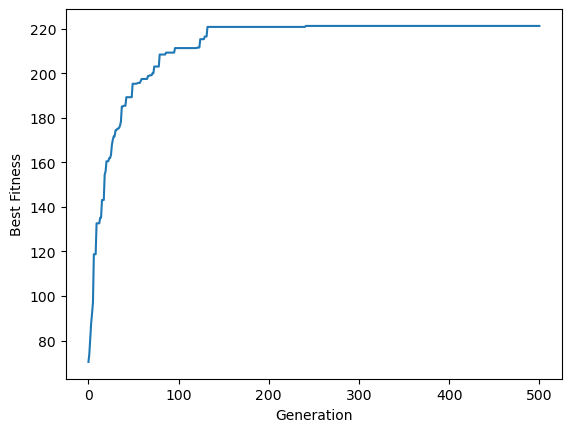

In [12]:
import matplotlib.pyplot as plt
plt.plot(opt.ga_instance.best_solutions_fitness)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')

In [13]:
assert False

AssertionError: 